# Part1 - Data Preprocessing
- load dataset
- normalize pixel values
- faltten input image to one dimension

In [1]:
import tensorflow as tf
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(len(X_train))
print(len(X_train[0]))

X_train = X_train / 255.0
X_test = X_test / 255

X_train_flatten = X_train.reshape(-1, 28 ** 2)
X_test_flatten = X_test.reshape(-1, 28 ** 2)

print(X_train_flatten.shape)
print(X_test_flatten.shape)
print(np.unique(y_train))


60000
28
(60000, 784)
(10000, 784)
[0 1 2 3 4 5 6 7 8 9]


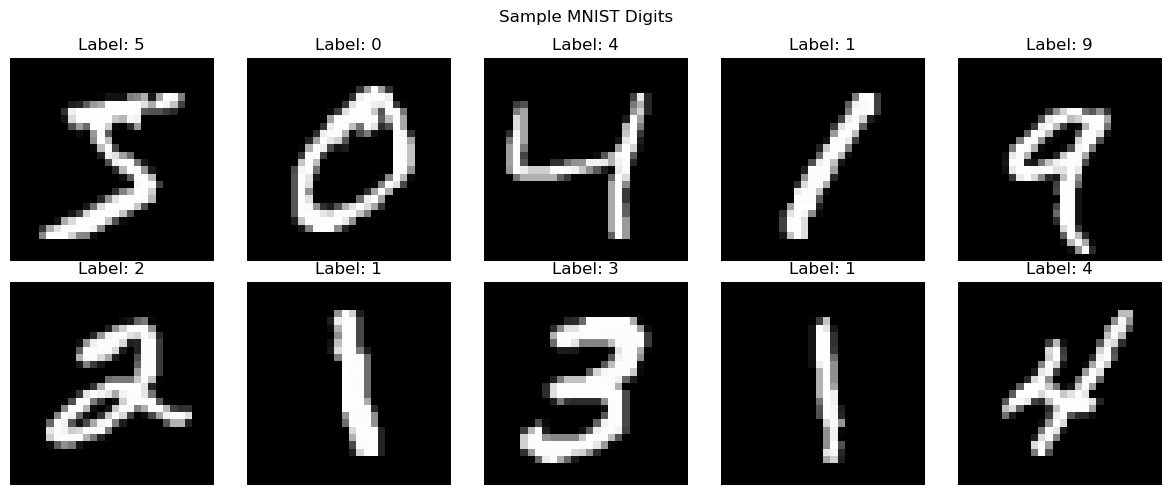

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.tight_layout()
plt.show()

# Part2 - Model Implementation
**a)**
- scikit-learn (MLP classifier)
- hidden layer(100-128)
- relu or tanh activation
- 10 output classes
- accuracy and confusion matrix

Iteration 1, loss = 0.29446999
Iteration 2, loss = 0.12886361
Iteration 3, loss = 0.08904527
Iteration 4, loss = 0.06771045
Iteration 5, loss = 0.05424276
Iteration 6, loss = 0.04372721
Iteration 7, loss = 0.03579996
Iteration 8, loss = 0.02909090
Iteration 9, loss = 0.02468030
Iteration 10, loss = 0.02118090
Iteration 11, loss = 0.01791395
Iteration 12, loss = 0.01404481
Iteration 13, loss = 0.01277836
Iteration 14, loss = 0.01163916
Iteration 15, loss = 0.01025981
Iteration 16, loss = 0.01019434
Iteration 17, loss = 0.00821592
Iteration 18, loss = 0.00825905
Iteration 19, loss = 0.00489565
Iteration 20, loss = 0.00855499
Accuracy:0.9779


d:\Info\AnacondaFolder\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


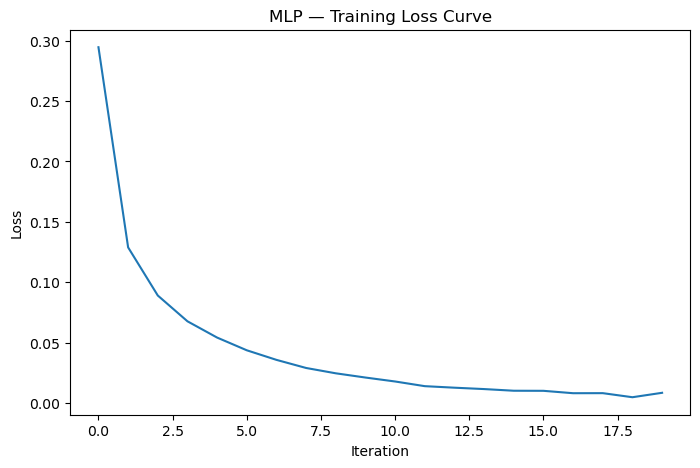

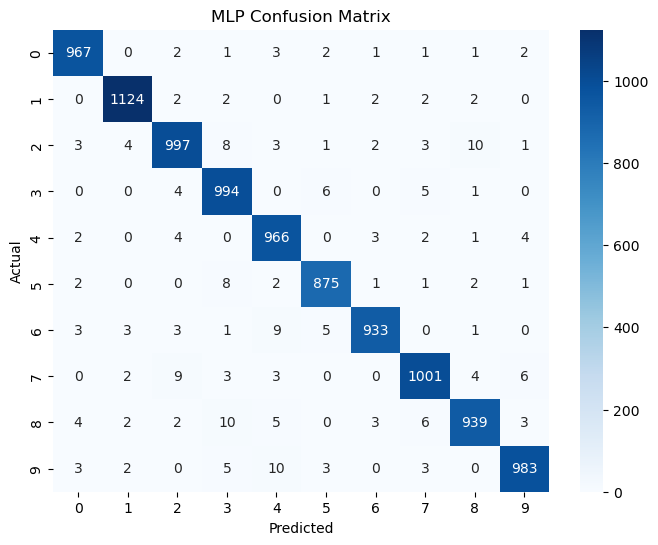

In [9]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    batch_size=64,
    max_iter=20,
    random_state=23,
    verbose=True
)

mlp.fit(X_train_flatten, y_train)
y_pred_mlp = mlp.predict(X_test_flatten)
mlp_acc = accuracy_score(y_test, y_pred_mlp)
print(f"Accuracy:{mlp_acc}")

plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.title('MLP — Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

cm = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**b)**
- use sequential
- use dense layers
- validation_split, learning_rate, batch_size, epochs
- plot training-validatiomn curves for each variation above and compare
- evaluate on test set + confusion matrix

In [2]:
# Test
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
import time
import pandas as pd

results = []

for epoch in [20]:
    for batch_size in [32, 64, 128]:
        for lr in [0.001]:
            for val_split in [0.1, 0.2]:
                model = Sequential([
                    Flatten(input_shape=(28, 28)),
                    Dense(128, activation='relu'),
                    Dense(10, activation='softmax')
                ])
                model.compile(
                    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy']
                )
                
                start = time.time()
                history = model.fit(X_train, y_train, epochs=epoch, batch_size=batch_size,
                                    validation_split=val_split, verbose=0)
                _, acc = model.evaluate(X_test, y_test, verbose=0)
                train_time = time.time() - start
                
                results.append({
                    'epochs': epoch,
                    'batch_size': batch_size,
                    'lr': lr,
                    'val_split': val_split,
                    'accuracy': acc,
                    'time': train_time,
                    'history': history.history  
                })
                
                print(f"Epochs({epoch}), batch_size({batch_size}), lr({lr}), val_split({val_split}) -> acc = {acc}, time = {train_time}s")

results_df = pd.DataFrame(results)
print("\nTop 5 results:")
print(results_df.nlargest(5, 'accuracy')[['epochs', 'batch_size', 'lr', 'val_split', 'accuracy', 'time']].to_string(index=False))

d:\Info\AnacondaFolder\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epochs(20), batch_size(32), lr(0.001), val_split(0.1) -> acc = 0.9789999723434448, time = 80.58497595787048s
Epochs(20), batch_size(32), lr(0.001), val_split(0.2) -> acc = 0.9775000214576721, time = 81.84419298171997s
Epochs(20), batch_size(64), lr(0.001), val_split(0.1) -> acc = 0.9771999716758728, time = 51.0596022605896s
Epochs(20), batch_size(64), lr(0.001), val_split(0.2) -> acc = 0.9761000275611877, time = 42.33272862434387s
Epochs(20), batch_size(128), lr(0.001), val_split(0.1) -> acc = 0.9763000011444092, time = 34.50362181663513s
Epochs(20), batch_size(128), lr(0.001), val_split(0.2) -> acc = 0.9775000214576721, time = 33.63675403594971s

Top 5 results:
 epochs  batch_size    lr  val_split  accuracy      time
     20          32 0.001        0.1    0.9790 80.584976
     20          32 0.001        0.2    0.9775 81.844193
     20         128 0.001        0.2    0.9775 33.636754
     20          64 0.001        0.1    0.9772 51.059602
     20         128 0.001        0.1    0.97

In [12]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
import time
import pandas as pd

results = []

for epoch in [5, 10, 20]:
    for batch_size in [32, 64, 128]:
        for lr in [0.01, 0.1]:
            for val_split in [0.1, 0.2, 0.4]:
                model = Sequential([
                    Flatten(input_shape=(28, 28)),
                    Dense(128, activation='relu'),
                    Dense(10, activation='softmax')
                ])
                model.compile(
                    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy']
                )
                
                start = time.time()
                history = model.fit(X_train, y_train, epochs=epoch, batch_size=batch_size,
                                    validation_split=val_split, verbose=0)
                _, acc = model.evaluate(X_test, y_test, verbose=0)
                train_time = time.time() - start
                
                results.append({
                    'epochs': epoch,
                    'batch_size': batch_size,
                    'lr': lr,
                    'val_split': val_split,
                    'accuracy': acc,
                    'time': train_time,
                    'history': history.history  
                })
                
                print(f"Epochs({epoch}), batch_size({batch_size}), lr({lr}), val_split({val_split}) -> acc = {acc}, time = {train_time}s")

results_df = pd.DataFrame(results)
print("\nTop 5 results:")
print(results_df.nlargest(5, 'accuracy')[['epochs', 'batch_size', 'lr', 'val_split', 'accuracy', 'time']].to_string(index=False))

Epochs(5), batch_size(32), lr(0.01), val_split(0.1) -> acc = 0.9546999931335449, time = 29.09532117843628s
Epochs(5), batch_size(32), lr(0.01), val_split(0.2) -> acc = 0.9577999711036682, time = 28.62061071395874s
Epochs(5), batch_size(32), lr(0.01), val_split(0.4) -> acc = 0.9502999782562256, time = 24.54961585998535s
Epochs(5), batch_size(32), lr(0.1), val_split(0.1) -> acc = 0.586899995803833, time = 28.876336812973022s
Epochs(5), batch_size(32), lr(0.1), val_split(0.2) -> acc = 0.5238999724388123, time = 24.895470142364502s
Epochs(5), batch_size(32), lr(0.1), val_split(0.4) -> acc = 0.5957000255584717, time = 24.326107263565063s
Epochs(5), batch_size(64), lr(0.01), val_split(0.1) -> acc = 0.9599000215530396, time = 15.421838521957397s
Epochs(5), batch_size(64), lr(0.01), val_split(0.2) -> acc = 0.9581999778747559, time = 15.256300449371338s
Epochs(5), batch_size(64), lr(0.01), val_split(0.4) -> acc = 0.955299973487854, time = 14.046288251876831s
Epochs(5), batch_size(64), lr(0.1), 

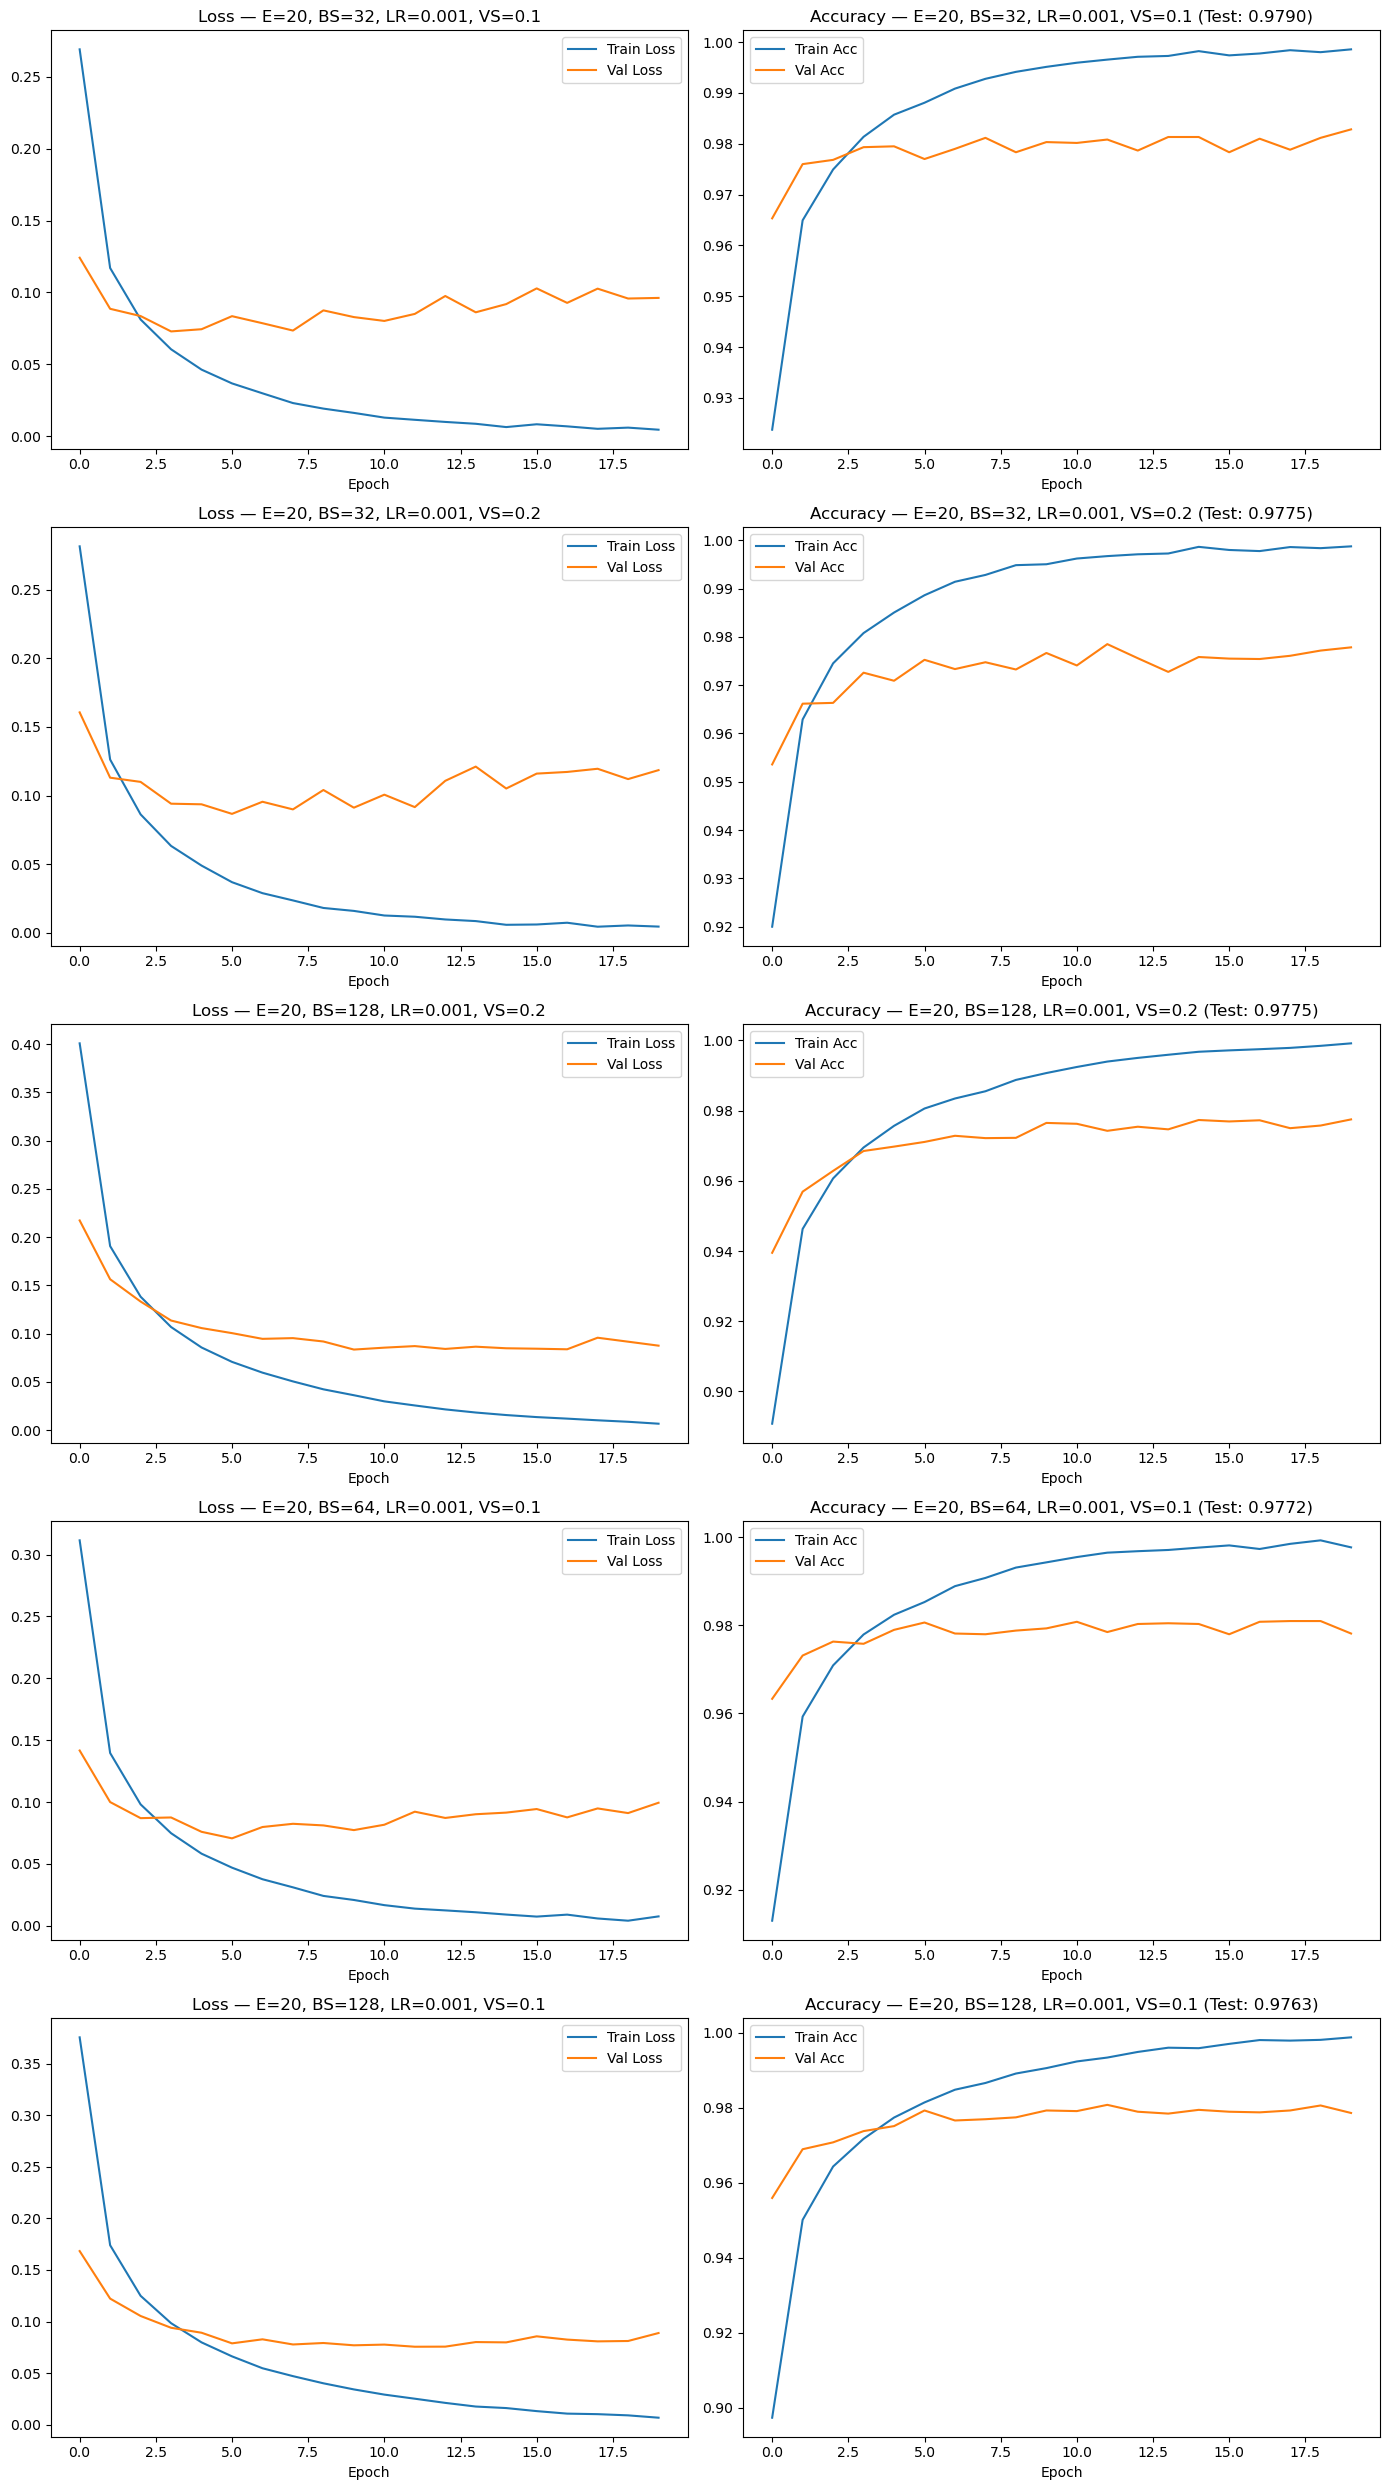

In [3]:
top_5 = results_df.nlargest(5, 'accuracy')

fig, axes = plt.subplots(5, 2, figsize=(14, 25))

for i, (_, row) in enumerate(top_5.iterrows()):
    h = row['history']
    label = f"E={row['epochs']}, BS={row['batch_size']}, LR={row['lr']}, VS={row['val_split']}"
    
    axes[i][0].plot(h['loss'], label='Train Loss')
    axes[i][0].plot(h['val_loss'], label='Val Loss')
    axes[i][0].set_title(f'Loss — {label}')
    axes[i][0].set_xlabel('Epoch')
    axes[i][0].legend()
    
    axes[i][1].plot(h['accuracy'], label='Train Acc')
    axes[i][1].plot(h['val_accuracy'], label='Val Acc')
    axes[i][1].set_title(f'Accuracy — {label} (Test: {row["accuracy"]:.4f})')
    axes[i][1].set_xlabel('Epoch')
    axes[i][1].legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9685 - loss: 0.1988
Best Model Test Accuracy: 0.9685
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


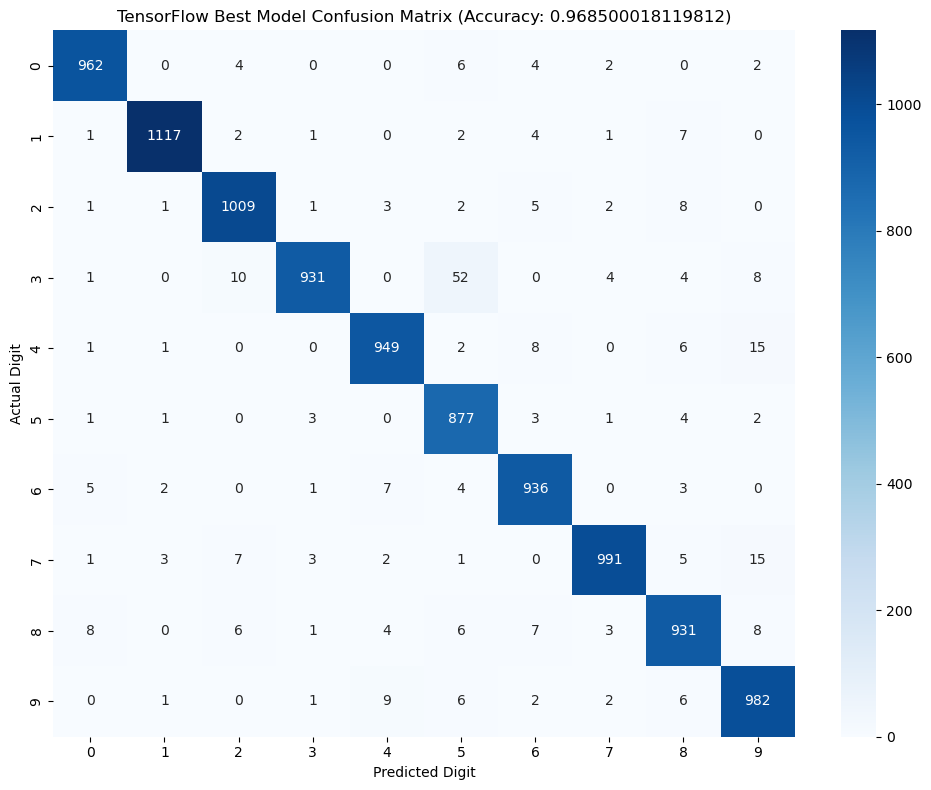

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.98      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.99      0.92      0.95      1010
           4       0.97      0.97      0.97       982
           5       0.92      0.98      0.95       892
           6       0.97      0.98      0.97       958
           7       0.99      0.96      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.95      0.97      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [15]:
# Confussion matrix of best result
best_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

best_model.fit(X_train, y_train, epochs=10, batch_size=128,
               validation_split=0.1, verbose=0)

_, best_acc = best_model.evaluate(X_test, y_test)
print(f"Best Model Test Accuracy: {best_acc:.4f}")

y_pred_tf = best_model.predict(X_test)
y_pred_tf_classes = np.argmax(y_pred_tf, axis=1)

cm = confusion_matrix(y_test, y_pred_tf_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'TensorFlow Best Model Confusion Matrix (Accuracy: {best_acc})')
plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_tf_classes))

# Performance Comparison
- easier to implement
- better performance

- **Discussion :** 
    - Implementation level :
        - arguably both of them are easy to implement , but scikit-learn wins because aside from selecting the params for the model, we basically just have to fit and predict and then get the results.On the other hand, tensorflow requires more decisions : we build the model layer by layer, we choose the output activation function, choose optimizer and loss function and then configure the training loop (epochs, batch_sie and validation split) in the fitting part.However for people that have previous experience with neural nets and like to tweak hyperparams this can be actually better.

    - Performance level :
        - both of them give the same performance 97% (the difference is very small for the same arhitecture(hidden layer)), but this also has to do with the performance level.The nice thing at tensorflow is the history object that offers us an indepth analysis (epoch training, validation curves for loss and accuracy) with this we obhserverd that mostly after 5 epochs the models actually overfit . Tensorflow is more customizable and more tunable by someone that knows what he is doing .

    - Conclusion :
        - scikit-learn should be used when we need a quick prototype and maybe we are not using just neural nets based models from the scikit-learn library, tensorflow should be used when we go through an in depth analysis over the results that can be achieved with neural nets. What we found is that the tf model obtained (the best one) is a lil bit better than the default from scikit learn (97.3% > 97%)